# 📈 Portfolio Performance Dashboard

A Python-based portfolio analysis tool that pulls real historical market data 
and calculates institutional-grade performance metrics for any combination of 
stocks.

## What this tool does
Enter any tickers, date range, portfolio weights, benchmark, and risk-free rate 
— and the tool does the rest. No code changes required.

## Metrics calculated
- **Total Return vs Benchmark** — compounded growth over the selected period
- **Correlation Heatmap within the Portfolio** - how correlated are the assets within the portfolio
- **Annualized Volatility** — how much the asset moves year over year
- **Sharpe Ratio** — return earned per unit of risk taken
- **Max Drawdown** — worst peak to trough decline experienced

## Visualizations
- Cumulative returns — portfolio vs benchmark vs individual holdings
- Drawdown chart — peak to trough declines across all assets
- Summary metrics — 4 panel bar chart across all holdings showing total return, volatility, max drawdown & sharpe ratio
- Correlation heatmap — how holdings move relative to each other

## Tech stack
Python | yfinance | pandas | numpy | matplotlib


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mtick

1. `import yfinance as yf` - Imports the Yahoo Finance API library, which allows you to download financial market data.

2. `import pandas as pd` - Imports the pandas library with the alias 'pd', used for data manipulation and analysis.

3. `import numpy as np` - Imports the NumPy library with the alias 'np', used for numerical computations.

4. `import matplotlib.pyplot as plt` - Imports the pyplot module from matplotlib with the alias 'plt', which provides a MATLAB-like plotting framework.

5. `import matplotlib.cm as cm` - Imports the colormap module from matplotlib, used for creating color maps for visualizations.

6. `import matplotlib.ticker as mtick` - Imports the ticker module from matplotlib, which provides tools for customizing axis tick marks and labels.

In [2]:
tickers_input = input("Enter tickers separated by commas: ")
tickers = [t.strip().upper() for t in tickers_input.split(',')]
start_date = input("Enter start date (YYYY-MM-DD): ")
end_date = input("Enter end date (YYYY-MM-DD): ")
print(f"Analyzing from {start_date} to {end_date}")
print("Your portfolio:", tickers)

Enter tickers separated by commas:  AMZN, META, AAPL, F
Enter start date (YYYY-MM-DD):  2020-01-01
Enter end date (YYYY-MM-DD):  2026-01-01


Analyzing from 2020-01-01 to 2026-01-01
Your portfolio: ['AMZN', 'META', 'AAPL', 'F']


1. `tickers_input = input("Enter tickers separated by commas: ")` - Prompts the user to enter stock ticker symbols separated by commas and stores the input as a string.

2. `tickers = [t.strip().upper() for t in tickers_input.split(',')]` - Processes the input string by:
   - Splitting it at each comma using `.split(',')`
   - Using a list comprehension to clean each ticker by removing whitespace with `.strip()` and converting to uppercase with `.upper()`

3. `start_date = input("Enter start date (YYYY-MM-DD): ")` - Prompts the user to enter a start date in the specified format.

4. `end_date = input("Enter end date (YYYY-MM-DD): ")` - Prompts the user to enter an end date.

5. `print(f"Analyzing from {start_date} to {end_date}")` - Displays the date range using an f-string.

6. `print("Your portfolio:", tickers)` - Displays the processed list of ticker symbols.

In [3]:
while True:
    weights_input = input("Enter weights as percentages e.g. 40, 40, 20: ")
    weights_pct = [float(w.strip()) for w in weights_input.split(',')]
    
    if round(sum(weights_pct), 2) != 100.0:
        print(f"Weights sum to {sum(weights_pct)}%. Must equal 100%. Try again.")
    else:
        weights = [w / 100 for w in weights_pct]
        weights_pct_dict = {ticker: f"{pct}%" for ticker, pct in zip(tickers, weights_pct)}
        print("Portfolio weights confirmed:", weights_pct_dict)
        break

Enter weights as percentages e.g. 40, 40, 20:  25,25,30,20


Portfolio weights confirmed: {'AMZN': '25.0%', 'META': '25.0%', 'AAPL': '30.0%', 'F': '20.0%'}


This code creates a loop that asks users to input portfolio weights as percentages and validates that they sum to 100%. Here's the step-by-step breakdown:

1. `while True:` - Creates an infinite loop that will continue until explicitly broken.

2. `weights_input = input("Enter weights as percentages e.g. 40, 40, 20: ")` - Prompts the user to enter percentage weights separated by commas.

3. `weights_pct = [float(w.strip()) for w in weights_input.split(',')]` - Splits the input string by commas, strips whitespace from each value, converts them to floating-point numbers, and stores them in a list.

4. The validation check:
   - `if round(sum(weights_pct), 2) != 100.0:` - Checks if the sum of percentages equals 100% (with rounding to handle floating-point precision).
   - If not equal to 100%, it displays an error message showing the current sum.

5. If the weights sum to 100%:
   - `weights = [w / 100 for w in weights_pct]` - Converts percentages to decimal values.
   - `weights_pct_dict = {ticker: f"{pct}%" for ticker, pct in zip(tickers, weights_pct)}` - Creates a dictionary mapping each ticker to its percentage weight.
   - Confirms the portfolio weights to the user.
   - `break` - Exits the loop once valid weights are provided.

In [4]:
BENCHMARK_OPTIONS = {
    '1': ('SPY', 'S&P 500'),
    '2': ('QQQ', 'Nasdaq-100'),
    '3': ('IWM', 'Russell 2000'),
    '4': ('VTI', 'Total US Market'),
}

print("\nChoose a benchmark:")
for key, (ticker, name) in BENCHMARK_OPTIONS.items():
    print(f"  {key}. {name} ({ticker})")

benchmark_choice = input("Enter number (or press Enter for S&P 500 default): ").strip()

if benchmark_choice in BENCHMARK_OPTIONS:
    BENCHMARK = BENCHMARK_OPTIONS[benchmark_choice][0]
else:
    BENCHMARK = 'SPY'

print(f"Benchmark set to: {BENCHMARK}")


Choose a benchmark:
  1. S&P 500 (SPY)
  2. Nasdaq-100 (QQQ)
  3. Russell 2000 (IWM)
  4. Total US Market (VTI)


Enter number (or press Enter for S&P 500 default):  SPY


Benchmark set to: SPY


The code creates a dictionary of benchmark options and prompts the user to choose one. Here is a step-by-step explanation:

1. BENCHMARK_OPTIONS is a dictionary where:
   - Keys are string numbers ('1', '2', '3', '4')
   - Values are tuples containing (ticker symbol, full name) for different market indices

2. The code prints a menu of benchmark options by looping through the dictionary items, displaying each option's number, name, and ticker symbol.

3. It then uses `input()` to prompt the user to select a benchmark by entering a number, with S&P 500 as the default option.

4. The conditional statement checks if the user's input matches any key in the dictionary:
   - If it does, it sets BENCHMARK to the corresponding ticker symbol
   - If not (including if the user just presses Enter), it defaults to 'SPY' (S&P 500)

5. Finally, it confirms the selected benchmark by printing it to the console.

In [5]:
all_tickers = list(dict.fromkeys(tickers + [BENCHMARK]))
prices = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
returns = prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


1. `all_tickers = list(dict.fromkeys(tickers + [BENCHMARK]))` - Creates a unique list of ticker symbols by:
   - Combining the `tickers` list with a benchmark ticker
   - Using `dict.fromkeys()` to remove any duplicates
   - Converting back to a list

2. `prices = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']` - Downloads historical stock price data:
   - Uses the Yahoo Finance API (`yf.download()`)
   - Gets data for all tickers between the specified date range
   - Sets `auto_adjust=False` to get unadjusted prices
   - Extracts only the 'Adj Close' price column

3. `returns = prices.pct_change().dropna()` - Calculates returns from the price data:
   - `pct_change()` computes the percentage change between consecutive prices
   - `dropna()` removes any rows with missing values (typically the first row)

In [6]:
returns.head()

Ticker,AAPL,AMZN,F,META,SPY
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.022293,-0.005291,-0.007572
2020-01-06,0.007968,0.014886,-0.005429,0.018833,0.003815
2020-01-07,-0.004703,0.002092,0.009825,0.002164,-0.002812
2020-01-08,0.016087,-0.007809,0.000000,0.010138,0.005330
2020-01-09,0.021241,0.004799,0.001081,0.014311,0.006781


The code `returns.head()` displays the first few rows of a DataFrame called `returns`. 

This method:
- Shows the first 5 rows by default (though you can specify a different number as an argument)
- Is commonly used to quickly inspect the structure and content of a DataFrame
- Helps verify that data has been loaded or transformed correctly

This is a standard pandas function used for data exploration to get a quick preview of your data.

In [7]:
total_return = (1 + returns).prod() - 1
print(total_return.round(4))

Ticker
AAPL    2.7514
AMZN    1.4322
F       0.8668
META    2.1686
SPY     1.2906
dtype: float64


1. `(1 + returns).prod()` - This adds 1 to each value in the `returns` series (converting each return to a growth factor), then uses the `prod()` method to multiply all these values together, giving the cumulative growth factor.

2. `- 1` - This subtracts 1 from the cumulative growth factor to convert it back to a return value.

3. `total_return = ...` - The result is stored in a variable called `total_return`.

4. `total_return.round(4)` - This rounds the total return value to 4 decimal places.

5. `print(...)` - This prints the rounded total return value.

This is a standard way to calculate the total return from a series of period returns in finance.

In [8]:
volatility = returns.std() * np.sqrt(252)
print(volatility.round(4))

Ticker
AAPL    0.3181
AMZN    0.3570
F       0.4283
META    0.4382
SPY     0.2075
dtype: float64


The code calculates and prints the annualized volatility of financial returns. Here's a step-by-step explanation:

1. `returns.std()` - Calculates the standard deviation of the returns data, which measures how much the returns fluctuate around their mean.

2. `* np.sqrt(252)` - Multiplies the standard deviation by the square root of 252. This is a common finance technique to annualize daily volatility, assuming there are 252 trading days in a year.

3. `volatility = ...` - Assigns the calculated annualized volatility to a variable named 'volatility'.

4. `print(volatility.round(4))` - Prints the volatility values rounded to 4 decimal places for readability.

This code is calculating a key financial risk metric that shows the expected annual price variation of the financial instruments in the returns data.

In [9]:
risk_free_input = input("Enter risk-free rate as percentage e.g. 4.5 for 4.5%: ")
RISK_FREE = float(risk_free_input.strip()) / 100
print(f"Risk-free rate set to: {risk_free_input.strip()}%")
excess_returns = returns.mean() * 252 - RISK_FREE
sharpe = excess_returns / volatility
print(sharpe.round(4))

Enter risk-free rate as percentage e.g. 4.5 for 4.5%:  4.5


Risk-free rate set to: 4.5%
Ticker
AAPL    0.7123
AMZN    0.4685
F       0.3526
META    0.5588
SPY     0.5553
dtype: float64


This code captures user input for a risk-free rate, converts it to a decimal value, and provides feedback to the user. Here's a step-by-step explanation:

1. `risk_free_input = input("Enter risk-free rate as percentage e.g. 4.5 for 4.5%: ")` - Prompts the user to enter a risk-free rate percentage and stores the input as a string.

2. `RISK_FREE = float(risk_free_input.strip()) / 100` - Converts the user input to a floating-point number after removing any leading/trailing whitespace with `.strip()`, then divides by 100 to convert from percentage to decimal form.

3. `print(f"Risk-free rate set to: {risk_free_input.strip()}%")` - Provides feedback to the user showing the risk-free rate they entered (with whitespace removed).

This code is part of what appears to be a financial analysis script, where the risk-free rate will be used in calculating excess returns and Sharpe ratios.

In [10]:
cumulative = (1 + returns).cumprod()
rolling_max = cumulative.cummax()

This code performs two operations on financial data, likely related to investment returns:

1. `cumulative = (1 + returns).cumprod()` - This line calculates the cumulative product of returns:
   - It first adds 1 to each value in the `returns` series/dataframe
   - Then applies `cumprod()` which computes the cumulative product along the index
   - This effectively converts individual period returns into cumulative returns over time, showing how an investment would grow

2. `rolling_max = cumulative.cummax()` - This line tracks the running maximum value:
   - It applies the `cummax()` method to the cumulative returns
   - This creates a series/dataframe where each value represents the highest cumulative return achieved up to that point
   - Often used to identify drawdowns or track high-water marks in investment performance

In [11]:
portfolio_returns = returns[tickers].dot(weights)
portfolio_cumulative = (1 + portfolio_returns).cumprod()
benchmark_cumulative = cumulative[BENCHMARK]

This code calculates portfolio returns and creates cumulative return series for both the portfolio and a benchmark. Here's a step-by-step explanation:

1. `portfolio_returns = returns[tickers].dot(weights)` - This calculates the weighted returns of the portfolio by:
   - Taking a subset of the `returns` DataFrame using the columns specified in `tickers`
   - Using the `.dot()` method to perform matrix multiplication with the `weights` array
   - The result is a Series representing the weighted returns of the portfolio for each time period

2. `portfolio_cumulative = (1 + portfolio_returns).cumprod()` - This calculates the cumulative returns of the portfolio by:
   - Adding 1 to each return value (converting returns to growth factors)
   - Applying the cumulative product function `.cumprod()` to calculate how an initial investment would grow over time

3. `benchmark_cumulative = cumulative[BENCHMARK]` - This extracts the cumulative returns of a benchmark from an existing `cumulative` DataFrame using the column specified by the `BENCHMARK` variable

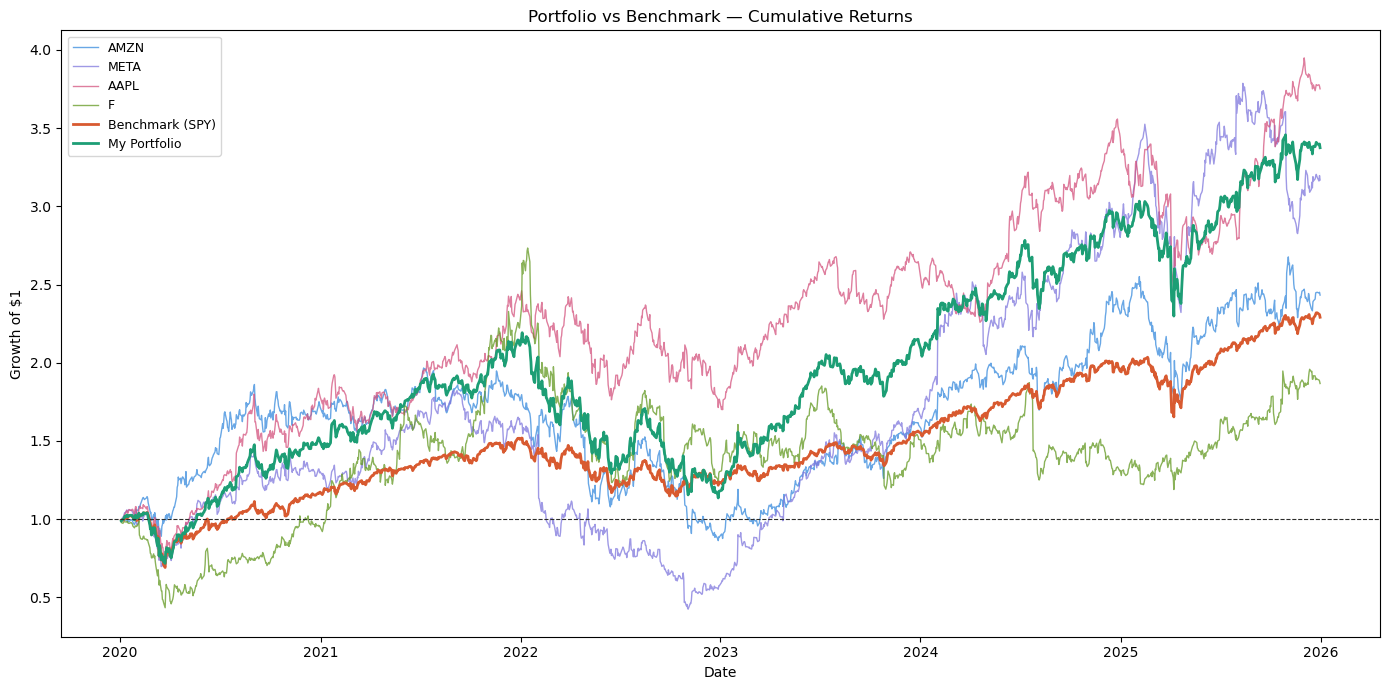

In [21]:
colormap = plt.colormaps['tab20'].resampled(len(tickers))
holding_colors = [colormap(i) for i in range(len(tickers))]

fig, ax = plt.subplots(figsize=(14, 7))

# Distinct colors for individual holdings
holding_colors = ['#378ADD', '#7F77DD', '#D4537E', '#639922', 
                  '#BA7517', '#0F6E56', '#993C1D', '#185FA5',
                  '#3C3489', '#3B6D11']

# Individual holdings — colored but thinner
for i, ticker in enumerate(tickers):
    ax.plot(cumulative.index, cumulative[ticker],
            color=holding_colors[i],
            linewidth=1, alpha=0.75, label=ticker)

# Benchmark — coral bold solid
ax.plot(cumulative.index, benchmark_cumulative,
        color='#D85A30', linewidth=2, label=f'Benchmark ({BENCHMARK})')

# Portfolio — teal boldest
ax.plot(cumulative.index, portfolio_cumulative,
        color='#1D9E75', linewidth=2, label='My Portfolio')

ax.set_title('Portfolio vs Benchmark — Cumulative Returns')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.axhline(y=1, color='#2C2C2A', linestyle='--', linewidth=0.8)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

This code creates a colormap for visualizing multiple stock tickers in a plot. Here's a step-by-step explanation:

1. `colormap = plt.colormaps['tab20'].resampled(len(tickers))` - This line gets the 'tab20' colormap from matplotlib's available colormaps and resamples it to match the number of tickers in your dataset. The 'tab20' colormap provides 20 distinct colors suitable for categorical data.

2. `holding_colors = [colormap(i) for i in range(len(tickers))]` - This creates a list of colors by extracting specific colors from the colormap. It uses a list comprehension to get one color for each ticker in your dataset.

This code ensures that each ticker will have its own distinct color in the plot, making it easier to distinguish between different securities in your portfolio visualization.

In [13]:
correlation = returns[tickers].corr()
print(correlation.round(2))

Ticker  AMZN  META  AAPL     F
Ticker                        
AMZN    1.00  0.62  0.59  0.27
META    0.62  1.00  0.55  0.28
AAPL    0.59  0.55  1.00  0.37
F       0.27  0.28  0.37  1.00


This code calculates and displays the correlation matrix between stock returns. Here's a step-by-step explanation:

1. `correlation = returns[tickers].corr()` - This line:
   - Takes the DataFrame `returns` and selects only the columns specified in the `tickers` list
   - Calls the `.corr()` method to calculate the correlation matrix between all pairs of stocks

2. `print(correlation.round(2))` - This line:
   - Takes the correlation matrix and rounds all values to 2 decimal places using the `.round(2)` method
   - Prints the rounded correlation matrix to the console

This code helps visualize how the returns of different stocks move in relation to each other, with values closer to 1 indicating stronger positive correlation.

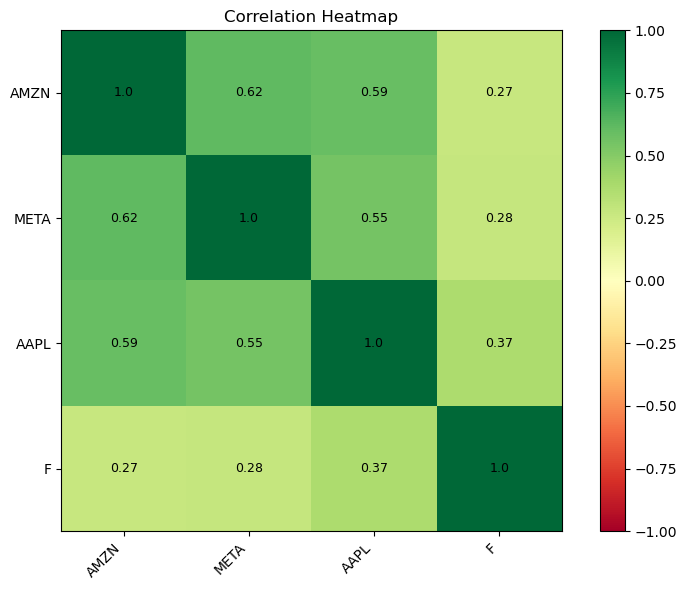

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(correlation, cmap='RdYlGn', vmin=-1, vmax=1)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, round(correlation.iloc[i, j], 2),
                ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

This code creates a figure with a single subplot for data visualization. Here's a step-by-step explanation:

1. `fig, ax = plt.subplots(figsize=(8, 6))` - This line creates a new Matplotlib figure and a single subplot (axis).

2. `figsize=(8, 6)` - This parameter sets the dimensions of the figure to 8 inches wide by 6 inches tall.

3. The function returns two objects:
   - `fig`: The overall figure object that contains everything
   - `ax`: The axes object where the actual plotting will occur

This is a common pattern in Matplotlib for creating visualizations, setting up the canvas before adding the actual plot elements.

In [15]:
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(max_drawdown.round(4))

Ticker
AAPL   -0.3336
AMZN   -0.5615
F      -0.5651
META   -0.7674
SPY    -0.3372
dtype: float64


This code calculates and prints the maximum drawdown value. Here's a step-by-step explanation:

1. `drawdown = (cumulative - rolling_max) / rolling_max` - This calculates the drawdown at each point by:
   - Taking the difference between the cumulative returns and the rolling maximum
   - Dividing by the rolling maximum to express it as a percentage/proportion

2. `max_drawdown = drawdown.min()` - This finds the minimum value in the drawdown series, which represents the maximum drawdown (the worst decline from a previous peak)

3. `print(max_drawdown.round(4))` - This prints the maximum drawdown value rounded to 4 decimal places

Maximum drawdown is an important risk metric in finance that measures the largest percentage drop from a peak to a subsequent trough in a time series.

In [16]:
summary = pd.DataFrame({
    'Total Return':   total_return.round(4),
    'Volatility':     volatility.round(4),
    'Sharpe Ratio':   sharpe.round(4),
    'Max Drawdown':   max_drawdown.round(4)
})
portfolio_total_return = (1 + portfolio_returns).prod() - 1
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)
portfolio_sharpe = (portfolio_returns.mean() * 252 - RISK_FREE) / portfolio_volatility
portfolio_drawdown = ((portfolio_cumulative - portfolio_cumulative.cummax()) / portfolio_cumulative.cummax()).min()

portfolio_row = pd.DataFrame({
    'Total Return': [round(portfolio_total_return, 4)],
    'Volatility': [round(portfolio_volatility, 4)],
    'Sharpe Ratio': [round(portfolio_sharpe, 4)],
    'Max Drawdown': [round(portfolio_drawdown, 4)]
}, index=['My Portfolio'])

summary_full = pd.concat([summary, portfolio_row])
print(summary_full)

              Total Return  Volatility  Sharpe Ratio  Max Drawdown
AAPL                2.7514      0.3181        0.7123       -0.3336
AMZN                1.4322      0.3570        0.4685       -0.5615
F                   0.8668      0.4283        0.3526       -0.5651
META                2.1686      0.4382        0.5588       -0.7674
SPY                 1.2906      0.2075        0.5553       -0.3372
My Portfolio        2.3747      0.2924        0.6881       -0.4822


This code creates a pandas DataFrame called `summary` that contains performance metrics for financial assets. Here's a step-by-step explanation:

1. `summary = pd.DataFrame({...})` - This creates a new DataFrame with the specified columns and data.

2. The DataFrame contains four financial performance metrics as columns:
   - `'Total Return'`: The overall investment return, rounded to 4 decimal places
   - `'Volatility'`: A measure of price fluctuation/risk, rounded to 4 decimal places
   - `'Sharpe Ratio'`: A measure of risk-adjusted return, rounded to 4 decimal places
   - `'Max Drawdown'`: The largest percentage drop from peak to trough, rounded to 4 decimal places

3. Each metric is passed as a pre-calculated variable (like `total_return`, `volatility`, etc.) with the `.round(4)` method applied to limit each value to 4 decimal places.

This DataFrame provides a clean, tabular summary of key performance metrics for financial analysis.






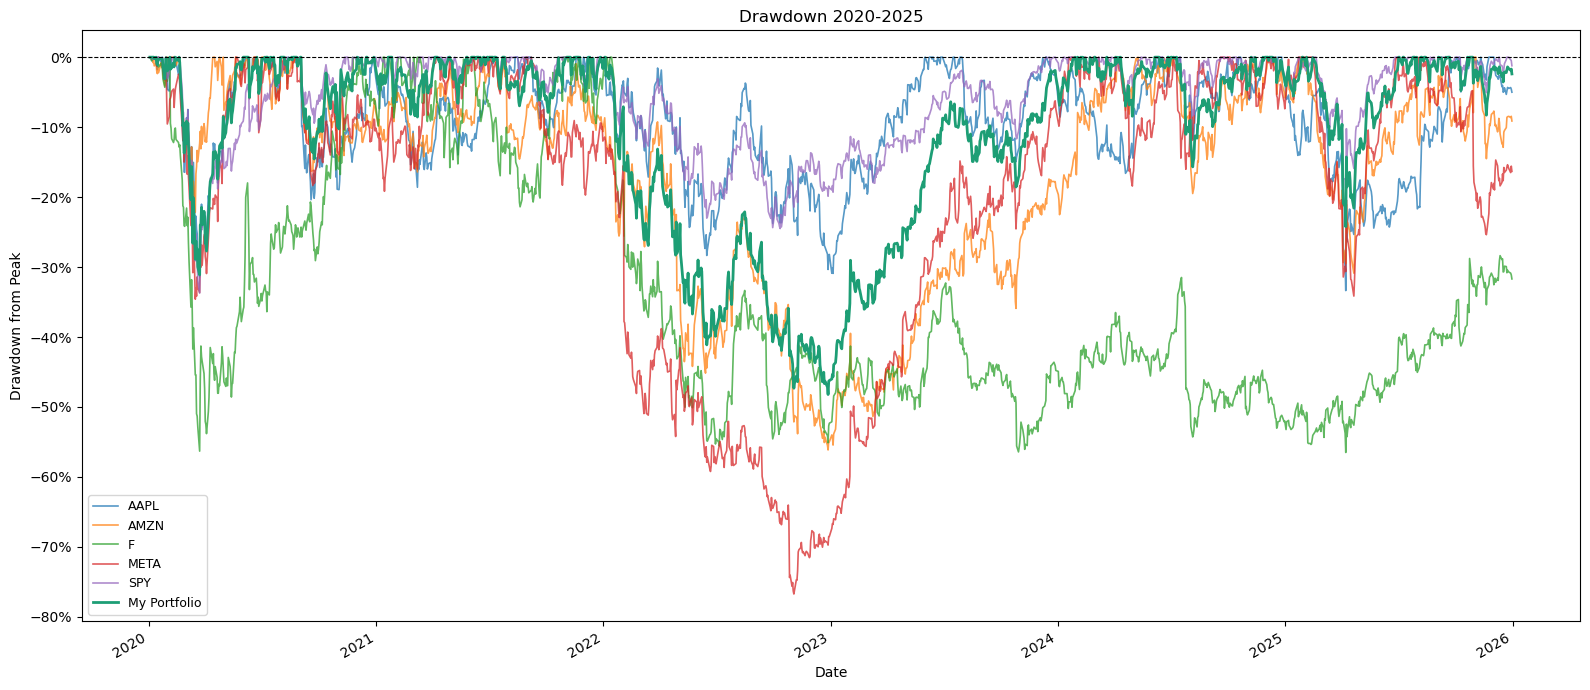

In [23]:
portfolio_drawdown_series = (portfolio_cumulative - portfolio_cumulative.cummax()) / portfolio_cumulative.cummax()

fig, ax = plt.subplots(figsize=(16, 7))
drawdown.plot(ax=ax, linewidth=1.2, alpha=0.75)
portfolio_drawdown_series.plot(ax=ax, color='#1D9E75', linewidth=2, label='My Portfolio')
ax.set_title('Drawdown 2020-2025')
ax.set_ylabel('Drawdown from Peak')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

This code creates and saves a visualization of portfolio drawdowns. Here's a step-by-step explanation:

1. `portfolio_drawdown_series = (portfolio_cumulative - portfolio_cumulative.cummax()) / portfolio_cumulative.cummax()` - Calculates the drawdown series for a portfolio by:
   - Finding the difference between current cumulative returns and the running maximum
   - Dividing by the running maximum to get percentage drawdown from peak

2. `fig, ax = plt.subplots(figsize=(16, 7))` - Creates a figure with a single subplot of size 16×7 inches

3. `drawdown.plot(ax=ax, linewidth=1.2, alpha=0.75)` - Plots an existing drawdown series (likely for benchmarks) with moderate transparency

4. `portfolio_drawdown_series.plot(ax=ax, color='#1D9E75', linewidth=2, label='My Portfolio')` - Plots the portfolio drawdown in green with thicker lines

5. `ax.set_title('Drawdown 2020-2025')` - Sets the chart title

6. `ax.set_ylabel('Drawdown from Peak')` and `ax.set_xlabel('Date')` - Sets axis labels

7. `ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))` - Formats y-axis values as percentages

8. `ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)` - Adds a horizontal reference line at y=0

9. `ax.legend(loc='lower left', fontsize=9)` - Adds a legend in the lower left corner

10. `plt.tight_layout()` and `plt.show()` - Adjusts spacing and displays the plot

11. `fig.savefig('drawdown.png', dpi=150, bbox_inches='tight')` - Saves the figure as a PNG file with high resolution

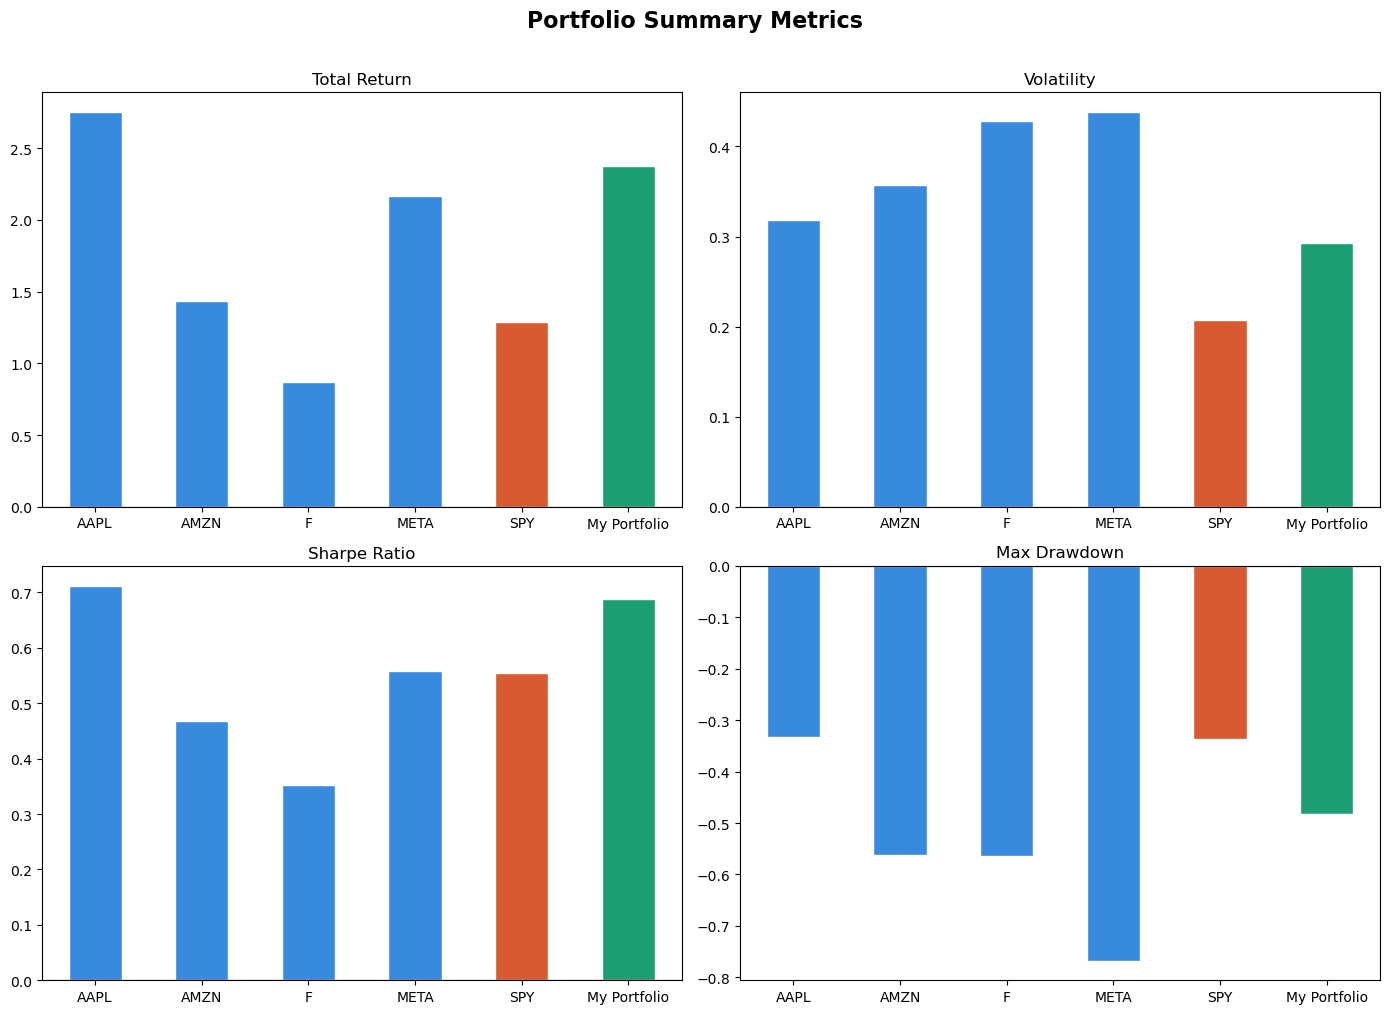

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Total Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown']

for i, metric in enumerate(metrics):
    ax = axes[i // 2, i % 2]
    summary_full[metric].plot(kind='bar', ax=ax, 
                               color=['#1D9E75' if x == 'My Portfolio' 
                                      else '#D85A30' if x == BENCHMARK
                                      else '#378ADD' for x in summary_full.index],
                               edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=360)
    ax.axhline(y=0, color='black', linewidth=0.8)

plt.suptitle('Portfolio Summary Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

This code creates a 2x2 grid of subplots within a single figure. Here's a step-by-step explanation:

1. `fig, axes = plt.subplots(2, 2, figsize=(14, 10))` - This line creates a new Matplotlib figure with:
   - 2 rows and 2 columns of subplots (for a total of 4 subplots)
   - A figure size of 14 inches wide by 10 inches tall
   - Returns the figure object as `fig` and an array of the subplot axes as `axes`

The `axes` variable will be a 2D array that can be indexed as `axes[row, column]` to access each individual subplot for further customization.

# Thank you!!